## 6.3 양자 메트롤로지 (Quantum Metrology)

In [1]:
from qiskit import QuantumCircuit, transpile  # 호환성 수정(qiskit 2.x): assemble 제거됨
from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt
from numpy import pi

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Aer 시뮬레이터 초기화
simulator = AerSimulator()
statevector_simulator = StatevectorSimulator()

In [3]:
# 측정용 큐비트 3개 + 고전 비트 3개로 양자 회로 정의
qc = QuantumCircuit(3, 3)

In [4]:
# 1단계: 초기 상태 준비 (첫 큐비트에 하다마드)
qc.h(0)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

In [5]:
# 2단계: 제어-U 연산 적용 (U는 Z축 회전)
qc.cp(pi/4, 0, 1)  # 제어-U1 게이트
qc.cp(pi/2, 0, 2)  # 제어-U2 게이트
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

In [6]:
# 3단계: 역 양자 푸리에 변환(QFT) 적용
qc.h(2)
qc.cp(-pi/4, 1, 2)
qc.h(1)
qc.cp(-pi/2, 0, 2)
qc.cp(-pi/4, 0, 1)
qc.h(0)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

In [7]:
# 4단계: 모든 큐비트 측정
qc.measure([0, 1, 2], [0, 1, 2])

Quantum Circuit before compilation:


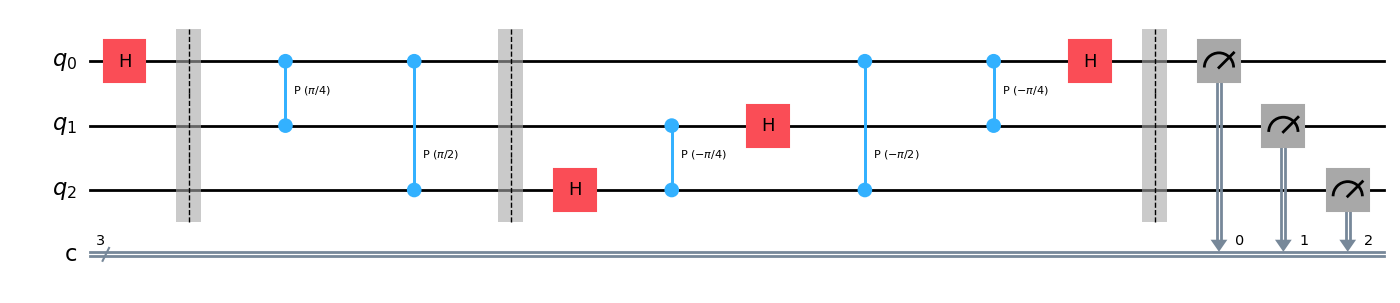

In [8]:
# 컴파일 전 양자 회로 그리기
print("Quantum Circuit before compilation:")
qc.draw('mpl')
plt.show()

In [9]:
# 시뮬레이터용으로 회로 트랜스파일
compiled_circuit = transpile(qc, simulator)


Quantum Circuit after compilation:


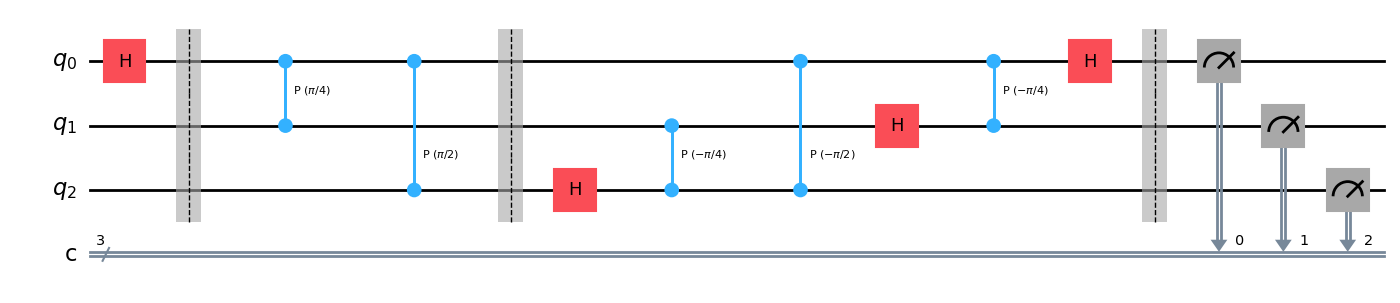

In [10]:
# 컴파일 후 양자 회로 그리기
print("\nQuantum Circuit after compilation:")
compiled_circuit.draw('mpl')
plt.show()

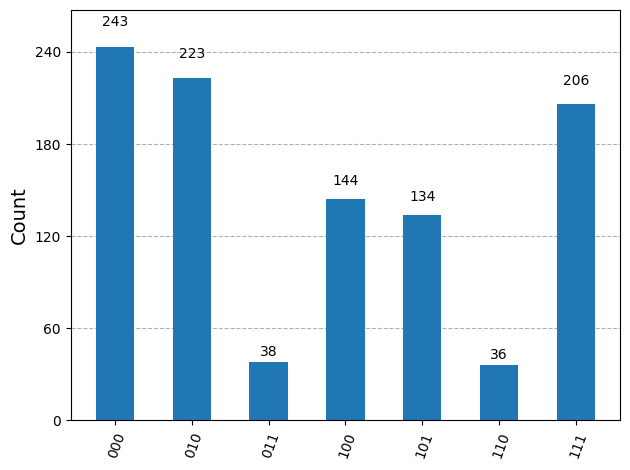

In [11]:
# 카운트용 실행 (호환성 수정: assemble 제거 → 트랜스파일된 회로를 그대로 run)
result_counts = simulator.run(compiled_circuit, shots=1024).result()
counts = result_counts.get_counts(compiled_circuit)
plot_histogram(counts)
plt.show()

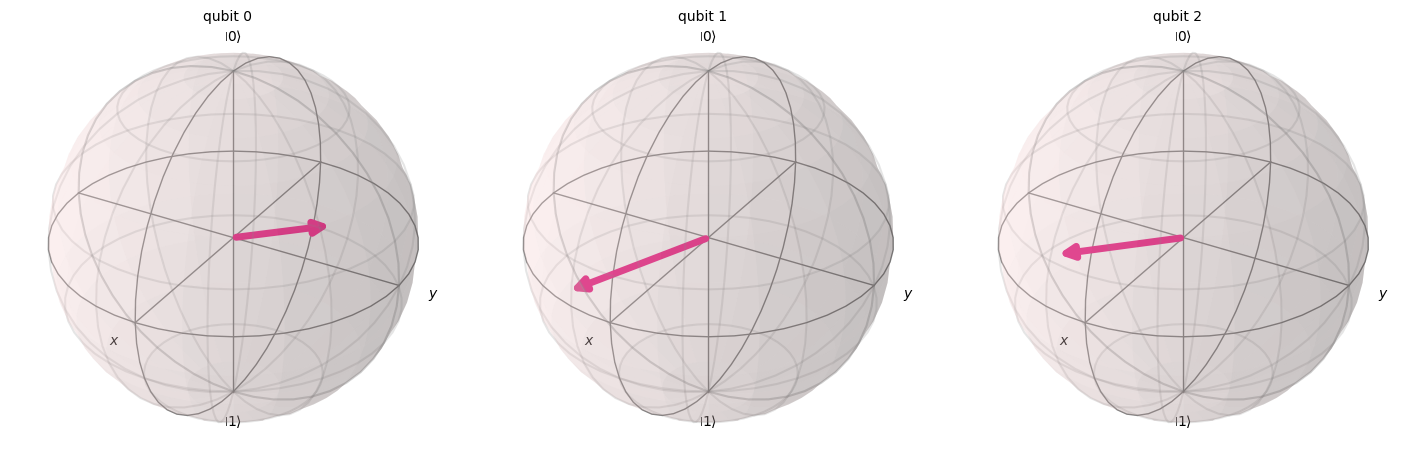

In [12]:
# 상태벡터용 실행 (호환성 수정: assemble 제거. 측정 없는 회로로 상태벡터 계산)
qc_sv = QuantumCircuit(3)
qc_sv.h(0); qc_sv.cp(pi/4, 0, 1); qc_sv.cp(pi/2, 0, 2)
qc_sv.h(2); qc_sv.cp(-pi/4, 1, 2); qc_sv.h(1); qc_sv.cp(-pi/2, 0, 2); qc_sv.cp(-pi/4, 0, 1); qc_sv.h(0)
compiled_sv = transpile(qc_sv, statevector_simulator)
result_statevector = statevector_simulator.run(compiled_sv).result()
statevector = result_statevector.get_statevector(compiled_sv)
plot_bloch_multivector(statevector)
plt.show()